In [1]:
import numpy as np
import matplotlib.pyplot as plt
from games.bos import BoS
from agents.regretmatching import RegretMatching
from agents.fictitiousplay import FictitiousPlay
from agents.random_agent import RandomAgent
from agents.iql import IndependentQLearning
from agents.jal_am import JointActionLearningAM

# Battle of the Sexes (BoS)

Es un juego en donde los jugadores deben elegir entre ir al **Cine** o a un **Partido** de fútbol. Prefieren ir juntos, pero agent_0 prefiere el Cine y agent_1 el Partido.

**A diferencia de Matching Pennies y Blotto, este juego NO es de suma cero**: ambos jugadores pueden obtener utilidad positiva simultáneamente.

Matrices de utilidades `(u₀, u₁)` (filas = agent_0, columnas = agent_1):

|              | **Cine**  | **Partido** |
|--------------|:---------:|:-----------:|
| **Cine**     | (2, 1)    | (0, 0)      |
| **Partido**  | (0, 0)    | (1, 2)      |

agent_0 obtiene más utilidad coordinando en Cine; agent_1, coincidiendo en Partido. La descoordinación da 0 a ambos.

In [2]:
g = BoS()

In [3]:
g.reset()

In [4]:
g.agents

['agent_0', 'agent_1']

In [5]:
move_labels = g._moves          # ['Cine', 'Partido']
R0 = g._R['agent_0']            # matriz de agent_0
R1 = g._R['agent_1']            # matriz de agent_1
n  = g._num_actions
move_labels

['Cine', 'Partido']

## Análisis

### Estrategias dominantes

**Ningún jugador tiene estrategia dominante** (ni fuerte ni débil):


### Equilibrios de Nash

**Dos equilibrios en estrategias puras:**

(Cine, Cine)       (2,  1) <br>
(Partido, Partido) (1, 2)

**Un equilibrio en estrategia mixta:**

Para que agent_0 sea indiferente entre Cine y Partido, agent_1 debe mezclar tal que:
`u₀(Cine) = u₀(Partido)` → `q·2 = (1−q)·1` → **q = 1/3** (P(agent_1 juega Cine))

Para que agent_1 sea indiferente:
`u₁(Cine) = u₁(Partido)` → `p·1 = (1−p)·2` → **p = 2/3** (P(agent_0 juega Cine))

| Agente  | P(Cine) | P(Partido) | Utilidad esperada |
|---------|---------|------------|-------------------|
| agent_0 | 2/3     | 1/3        | **2/3 ≈ 0.667**  |
| agent_1 | 1/3     | 2/3        | **2/3 ≈ 0.667**  |

El EN mixto da a ambos jugadores una utilidad esperada de 2/3, **menor que cualquier EN puro** (que da al menos 1 al peor agente). El conflicto de coordinación hace que la solución mixta sea ineficiente. Los algoritmos de aprendizaje tienden a converger a uno de los EN puros, dependiendo de las condiciones iniciales y el oponente.

In [6]:
def play_game(game, agents, n_rounds=10000):
    """Reinicia el juego, ejecuta n_rounds rondas y retorna las políticas finales."""
    game.reset()
    for _ in range(n_rounds):
        actions = {a: agents[a].action() for a in game.agents}
        game.step(actions)
    return {a: agents[a].policy() for a in game.agents}


def track_convergence(game, agents, checkpoints):
    """Registra P(Cine) = policy()[0] en cada checkpoint. Retorna dict de historiales."""
    game.reset()
    history = {a: [] for a in game.agents}
    step = 0
    for cp in checkpoints:
        for _ in range(cp - step):
            actions = {a: agents[a].action() for a in game.agents}
            game.step(actions)
        step = cp
        for a in game.agents:
            history[a].append(agents[a].policy()[0])
    return history


def plot_convergence(history, checkpoints, title):
    """Grafica P(Cine) de cada agente con los tres equilibrios de Nash como referencia."""
    fig, ax = plt.subplots(figsize=(9, 5))
    for agent, values in history.items():
        ax.plot(checkpoints, values, marker='o', label=agent)
    ax.axhline(1.0, color='green',  linestyle='--', alpha=0.6, label='EN puro: (Cine, Cine) — P(Cine)=1')
    ax.axhline(0.0, color='red',    linestyle='--', alpha=0.6, label='EN puro: (Partido, Partido) — P(Cine)=0')
    ax.axhline(2/3, color='blue',   linestyle=':',  alpha=0.7, label='EN mixto agent_0: P(Cine)=2/3')
    ax.axhline(1/3, color='orange', linestyle=':',  alpha=0.7, label='EN mixto agent_1: P(Cine)=1/3')
    ax.set_xscale('log')
    ax.set_xlabel('Rondas (escala log)')
    ax.set_ylabel('P(jugar Cine)')
    ax.set_title(title)
    ax.legend(loc='center right', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.05)
    plt.tight_layout()
    plt.show()

## Experimentos: política final aprendida

Para cada experimento se muestra la política final aprendida y la acción preferida (argmax). Dada la estructura del juego, esperamos convergencia a uno de los dos equilibrios de Nash puros.

### Regret Matching vs Regret Matching

In [7]:
agents = {a: RegretMatching(game=g, agent=a) for a in g.agents}
policies = play_game(g, agents)
{a: dict(zip(move_labels, policies[a].round(3))) for a in g.agents}

{'agent_0': {'Cine': np.float64(1.0), 'Partido': np.float64(0.0)},
 'agent_1': {'Cine': np.float64(0.999), 'Partido': np.float64(0.001)}}

In [8]:
# Acción preferida (argmax)
{a: g._moves[np.argmax(policies[a])] for a in g.agents}

{'agent_0': 'Cine', 'agent_1': 'Cine'}

### Regret Matching vs Random Agent

In [9]:
agents = {'agent_0': RegretMatching(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
policies = play_game(g, agents)
{a: dict(zip(move_labels, policies[a].round(3))) for a in g.agents}

{'agent_0': {'Cine': np.float64(1.0), 'Partido': np.float64(0.0)},
 'agent_1': {'Cine': np.float64(0.5), 'Partido': np.float64(0.5)}}

In [10]:
# Acción preferida (argmax)
{a: g._moves[np.argmax(policies[a])] for a in g.agents}

{'agent_0': 'Cine', 'agent_1': 'Cine'}

### Fictitious Play vs Fictitious Play

In [11]:
agents = {a: FictitiousPlay(game=g, agent=a) for a in g.agents}
policies = play_game(g, agents)
{a: dict(zip(move_labels, policies[a].round(3))) for a in g.agents}

{'agent_0': {'Cine': np.float64(0.999), 'Partido': np.float64(0.001)},
 'agent_1': {'Cine': np.float64(0.999), 'Partido': np.float64(0.001)}}

In [12]:
# Acción preferida (argmax)
{a: g._moves[np.argmax(policies[a])] for a in g.agents}

{'agent_0': 'Cine', 'agent_1': 'Cine'}

### Fictitious Play vs Random Agent

In [13]:
agents = {'agent_0': FictitiousPlay(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
policies = play_game(g, agents)
{a: dict(zip(move_labels, policies[a].round(3))) for a in g.agents}

{'agent_0': {'Cine': np.float64(0.999), 'Partido': np.float64(0.001)},
 'agent_1': {'Cine': np.float64(0.5), 'Partido': np.float64(0.5)}}

In [14]:
# Acción preferida (argmax)
{a: g._moves[np.argmax(policies[a])] for a in g.agents}

{'agent_0': 'Cine', 'agent_1': 'Cine'}

### IQL vs Random Agent

In [15]:
agents = {'agent_0': IndependentQLearning(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
policies = play_game(g, agents)
{a: dict(zip(move_labels, policies[a].round(3))) for a in g.agents}

{'agent_0': {'Cine': np.float64(0.768), 'Partido': np.float64(0.232)},
 'agent_1': {'Cine': np.float64(0.5), 'Partido': np.float64(0.5)}}

In [16]:
# Acción preferida (argmax)
{a: g._moves[np.argmax(policies[a])] for a in g.agents}

{'agent_0': 'Cine', 'agent_1': 'Cine'}

### IQL vs IQL

In [17]:
agents = {a: IndependentQLearning(game=g, agent=a) for a in g.agents}
policies = play_game(g, agents)
{a: dict(zip(move_labels, policies[a].round(3))) for a in g.agents}

{'agent_0': {'Cine': np.float64(0.974), 'Partido': np.float64(0.026)},
 'agent_1': {'Cine': np.float64(0.932), 'Partido': np.float64(0.068)}}

In [18]:
# Acción preferida (argmax)
{a: g._moves[np.argmax(policies[a])] for a in g.agents}

{'agent_0': 'Cine', 'agent_1': 'Cine'}

### IQL vs Joint Action Learning AM

In [19]:
agents = {'agent_0': IndependentQLearning(game=g, agent='agent_0'), 'agent_1': JointActionLearningAM(game=g, agent='agent_1')}
policies = play_game(g, agents)
{a: dict(zip(move_labels, policies[a].round(3))) for a in g.agents}

{'agent_0': {'Cine': np.float64(0.239), 'Partido': np.float64(0.761)},
 'agent_1': {'Cine': np.float64(0.0), 'Partido': np.float64(1.0)}}

In [20]:
# Acción preferida (argmax)
{a: g._moves[np.argmax(policies[a])] for a in g.agents}

{'agent_0': 'Partido', 'agent_1': 'Partido'}

### Joint Action Learning AM vs Joint Action Learning AM

In [21]:
agents = {a: JointActionLearningAM(game=g, agent=a) for a in g.agents}
policies = play_game(g, agents)
{a: dict(zip(move_labels, policies[a].round(3))) for a in g.agents}

{'agent_0': {'Cine': np.float64(0.993), 'Partido': np.float64(0.007)},
 'agent_1': {'Cine': np.float64(0.787), 'Partido': np.float64(0.213)}}

In [22]:
# Acción preferida (argmax)
{a: g._moves[np.argmax(policies[a])] for a in g.agents}

{'agent_0': 'Cine', 'agent_1': 'Cine'}

## Análisis de Convergencia

Se registra **P(Cine)** de cada agente a lo largo del tiempo.

Referencias en los gráficos:
- Verde discontinua: EN puro (Cine, Cine) → P(Cine) = 1
- Roja discontinua: EN puro (Partido, Partido) → P(Cine) = 0
- Azul punteada: EN mixto para agent_0 → P(Cine) = 2/3
- Naranja punteada: EN mixto para agent_1 → P(Cine) = 1/3

In [23]:
checkpoints = [10, 50, 100, 500, 1000, 5000, 10000]

### Regret Matching vs Regret Matching

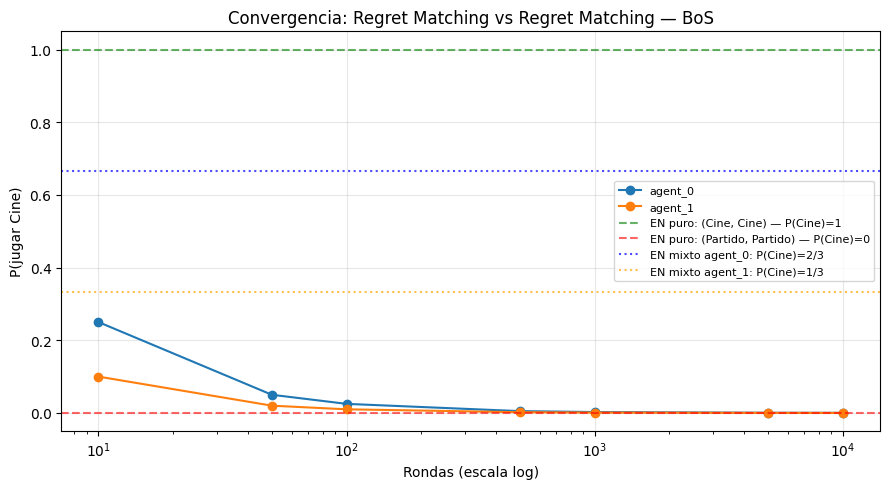

In [24]:
agents = {a: RegretMatching(game=g, agent=a) for a in g.agents}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia: Regret Matching vs Regret Matching — BoS')

### Regret Matching vs Random Agent

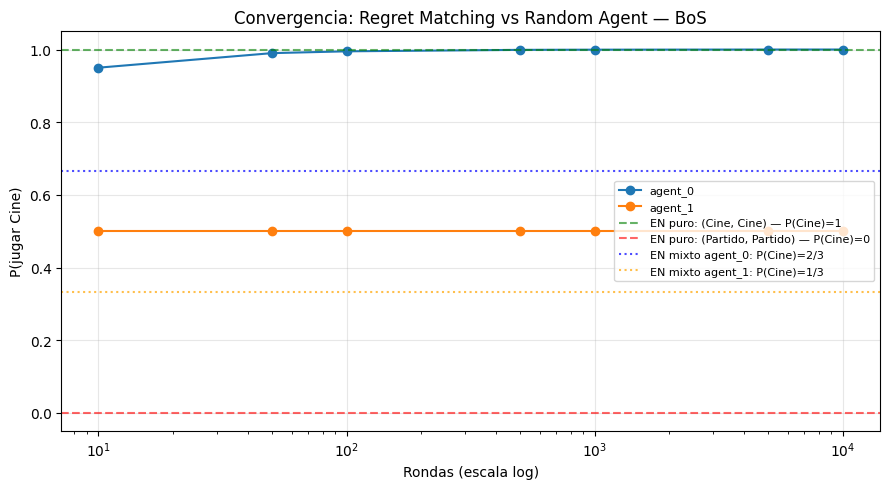

In [25]:
agents = {'agent_0': RegretMatching(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia: Regret Matching vs Random Agent — BoS')

### Fictitious Play vs Fictitious Play

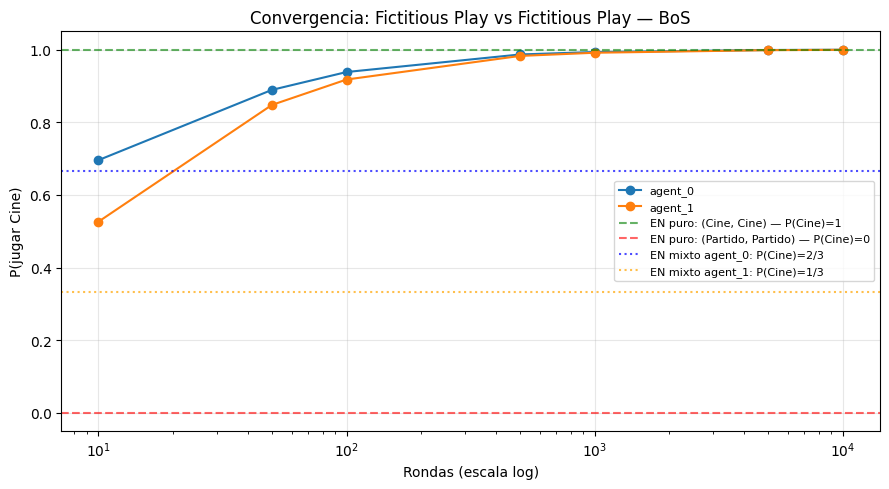

In [26]:
agents = {a: FictitiousPlay(game=g, agent=a) for a in g.agents}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia: Fictitious Play vs Fictitious Play — BoS')

### Fictitious Play vs Random Agent

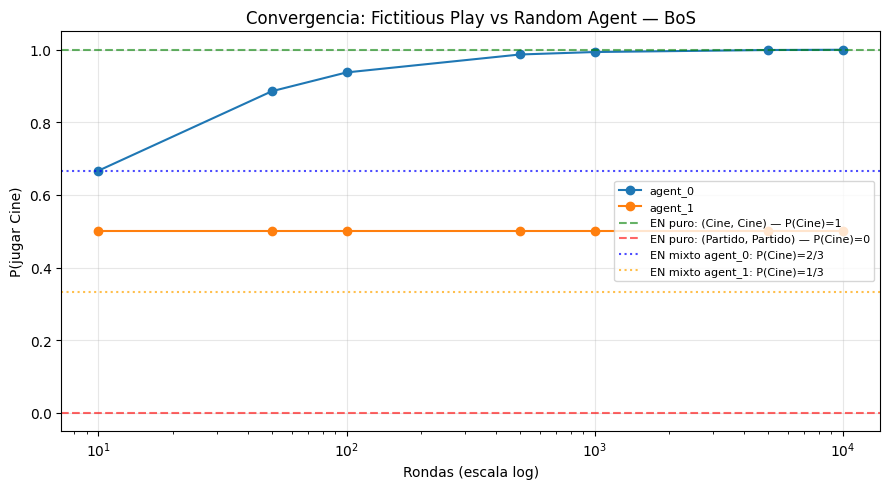

In [27]:
agents = {'agent_0': FictitiousPlay(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia: Fictitious Play vs Random Agent — BoS')

### IQL vs Random Agent

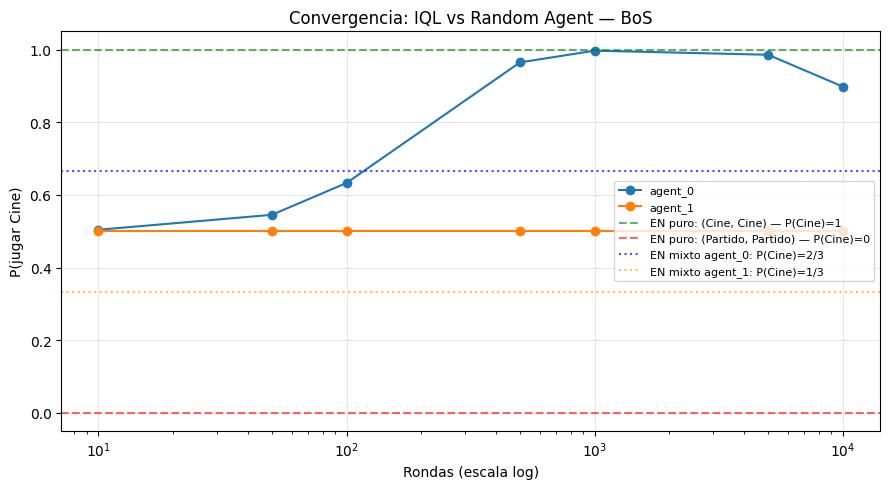

In [28]:
agents = {'agent_0': IndependentQLearning(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia: IQL vs Random Agent — BoS')

### IQL vs IQL

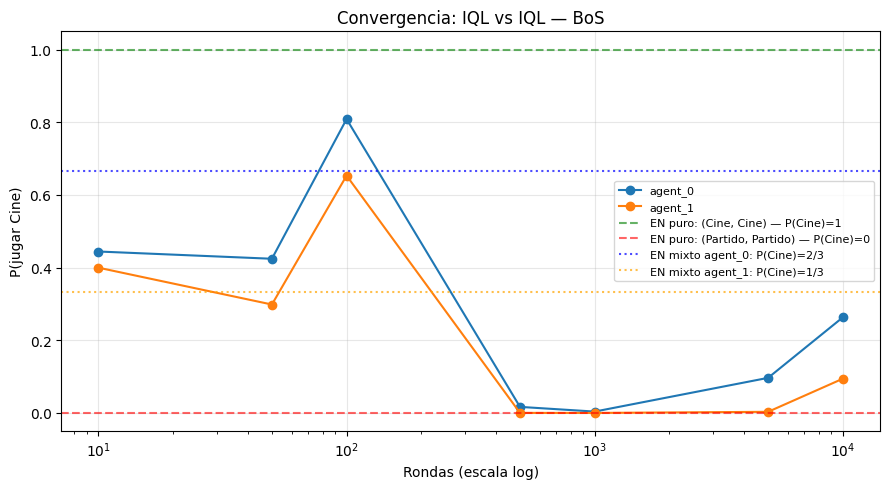

In [29]:
agents = {a: IndependentQLearning(game=g, agent=a) for a in g.agents}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia: IQL vs IQL — BoS')

### Joint Action Learning AM vs Joint Action Learning AM

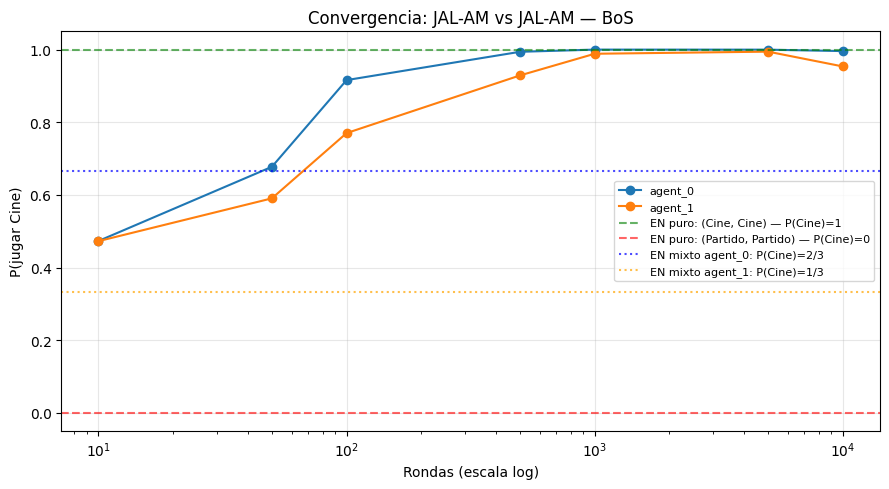

In [30]:
agents = {a: JointActionLearningAM(game=g, agent=a) for a in g.agents}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia: JAL-AM vs JAL-AM — BoS')

## Histograma de Acciones Tomadas

Para cada combinación de algoritmos se muestra cuántas veces eligió cada acción durante 10.000 rondas. Permite identificar visualmente hacia qué equilibrio convergen (Cine ↔ EN (Cine,Cine), Partido ↔ EN (Partido,Partido)).

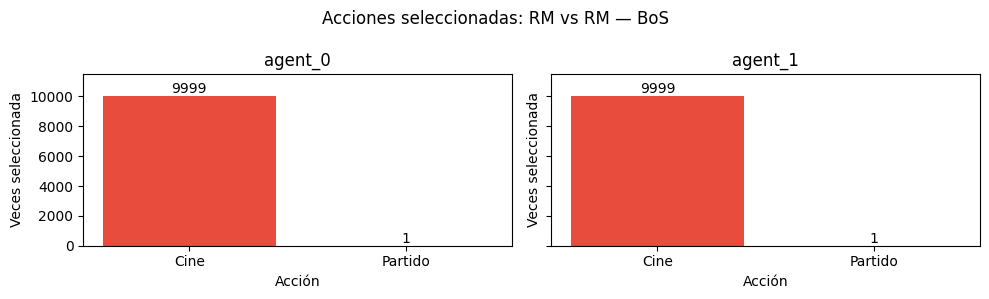

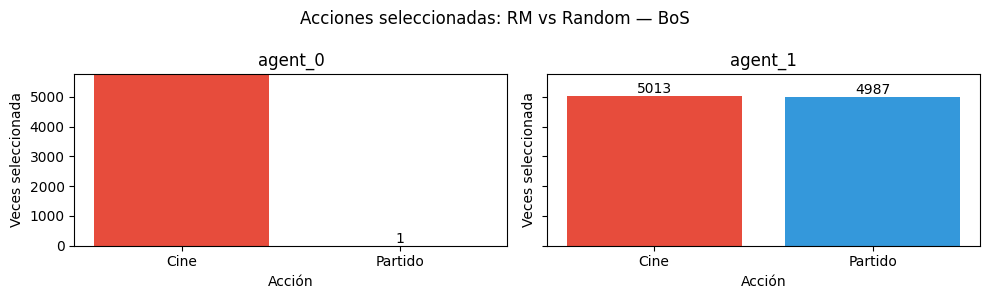

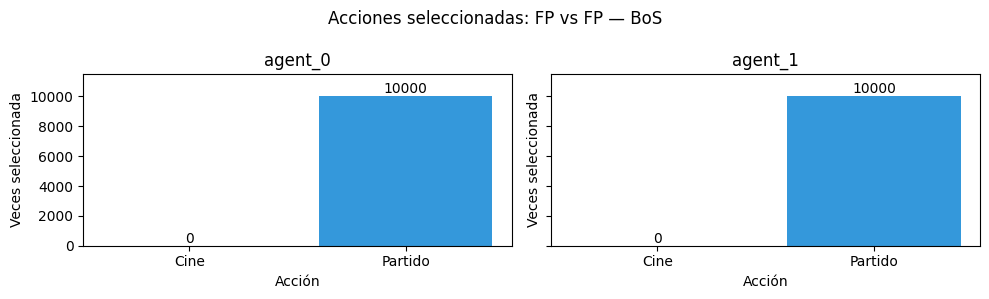

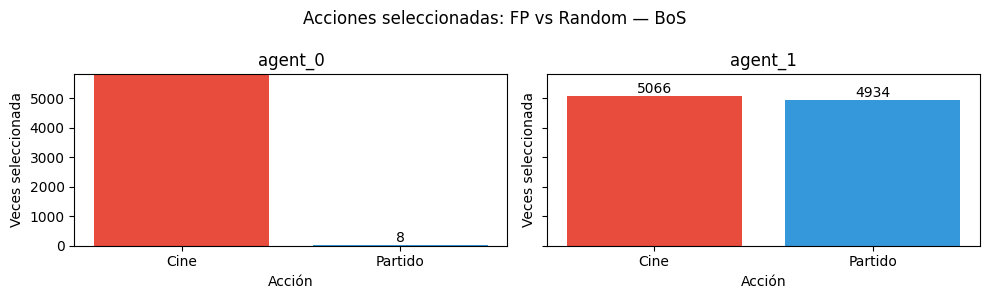

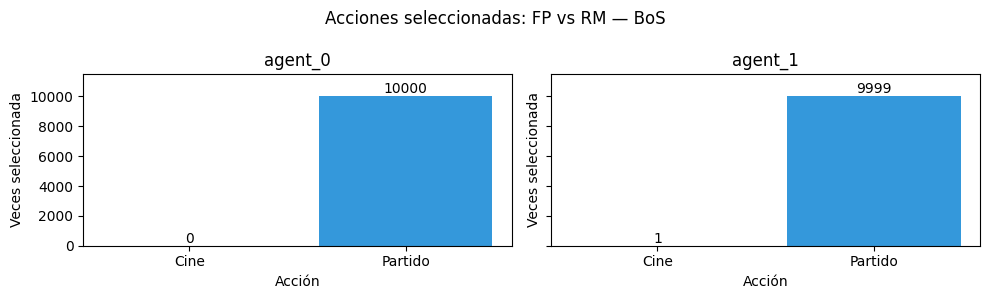

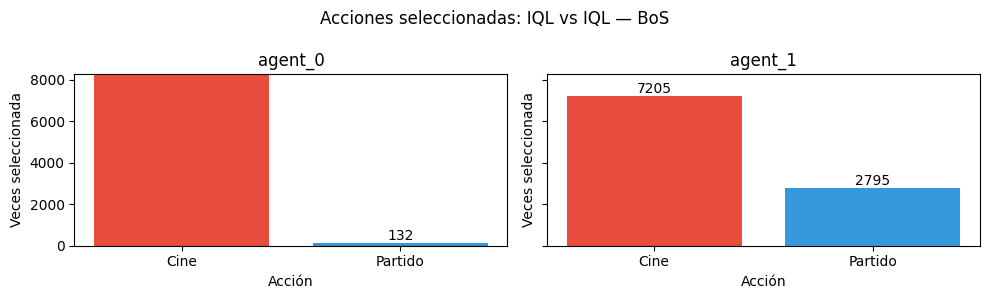

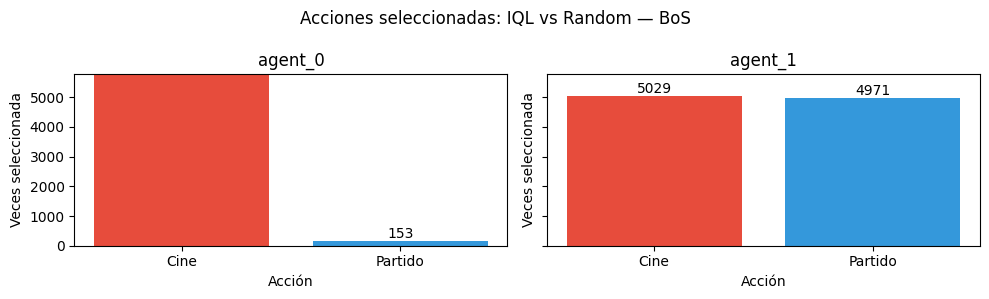

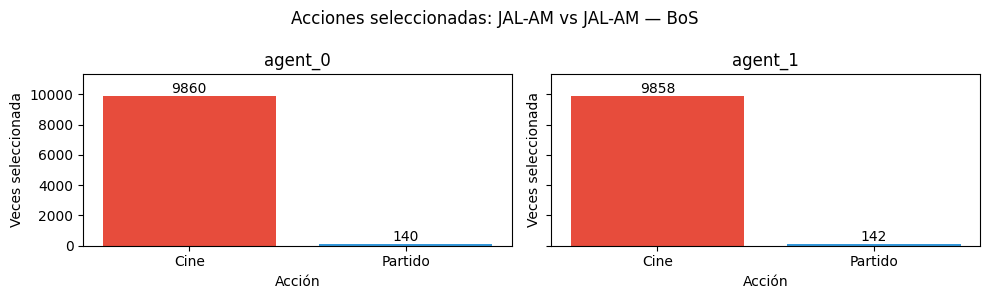

In [31]:

def play_game_with_counts(game, agents, n_rounds=10000):
    """Ejecuta n_rounds y retorna políticas y conteo de acciones por agente."""
    game.reset()
    action_counts = {a: np.zeros(game._num_actions, dtype=int) for a in game.agents}
    for _ in range(n_rounds):
        actions = {a: agents[a].action() for a in game.agents}
        for a in game.agents:
            action_counts[a][actions[a]] += 1
        game.step(actions)
    return {a: agents[a].policy() for a in game.agents}, action_counts


def plot_action_histogram(action_counts, moves, title=''):
    """Histograma de acciones seleccionadas por cada agente."""
    colors = ['#e74c3c', '#3498db']
    fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
    for ax, agent in zip(axes, list(action_counts.keys())):
        counts = action_counts[agent]
        bars = ax.bar(moves, counts, color=colors[:len(moves)])
        ax.bar_label(bars, fmt='%d')
        ax.set_title(agent)
        ax.set_xlabel('Acción')
        ax.set_ylabel('Veces seleccionada')
        ax.set_ylim(0, max(counts) * 1.15)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


histogram_matchups = [
    ('RM vs RM',
     {a: RegretMatching(game=g, agent=a) for a in g.agents}),
    ('RM vs Random',
     {'agent_0': RegretMatching(game=g, agent='agent_0'),
      'agent_1': RandomAgent(game=g, agent='agent_1')}),
    ('FP vs FP',
     {a: FictitiousPlay(game=g, agent=a) for a in g.agents}),
    ('FP vs Random',
     {'agent_0': FictitiousPlay(game=g, agent='agent_0'),
      'agent_1': RandomAgent(game=g, agent='agent_1')}),
    ('FP vs RM',
     {'agent_0': FictitiousPlay(game=g, agent='agent_0'),
      'agent_1': RegretMatching(game=g, agent='agent_1')}),
    ('IQL vs IQL',
     {a: IndependentQLearning(game=g, agent=a) for a in g.agents}),
    ('IQL vs Random',
     {'agent_0': IndependentQLearning(game=g, agent='agent_0'),
      'agent_1': RandomAgent(game=g, agent='agent_1')}),
    ('JAL-AM vs JAL-AM',
     {a: JointActionLearningAM(game=g, agent=a) for a in g.agents}),
]
for title, agents in histogram_matchups:
    _, counts = play_game_with_counts(g, agents)
    plot_action_histogram(counts, move_labels, f'Acciones seleccionadas: {title} — BoS')


## Análisis de Rewards

Se extiende el análisis con `N_SEEDS = 10` semillas y `N_EPISODES = 10.000` episodios. Para cada matchup se muestran tres gráficas:

1. **Reward promedio** con banda ±1 std. En BoS los posibles resultados son: Cine+Cine=(2,1), Partido+Partido=(1,2), descoordinación=(0,0).
2. **Distancia L1 al EN mixto** $\|\pi_0 - [2/3, 1/3]\|_1$. Nota: distancia alta indica convergencia a un **EN puro** (también válido y de mayor reward).
3. **P(Cine) actual vs. promedio acumulado** (seed 0), con líneas de referencia para los tres equilibrios.

In [32]:

import os
from utils.experiment import run_experiment, run_experiment_and_plot
from utils.io import save_results
from utils.plotting import plot_with_ci, smooth
from utils.metrics import dist_to_ne
from utils.constants import COLORS, IQL_KWARGS, JALAM_KWARGS

N_EPISODES = 10_000
N_SEEDS    = 10
# EN mixto de BoS: agent_0 juega Cine con p=2/3, agent_1 con p=1/3
NE_BOS     = np.array([2/3, 1/3])
os.makedirs('results/BoS', exist_ok=True)
os.makedirs('figures/BoS', exist_ok=True)


#### RM vs RM

Saved → results/BoS/RM_vs_RM/results.json


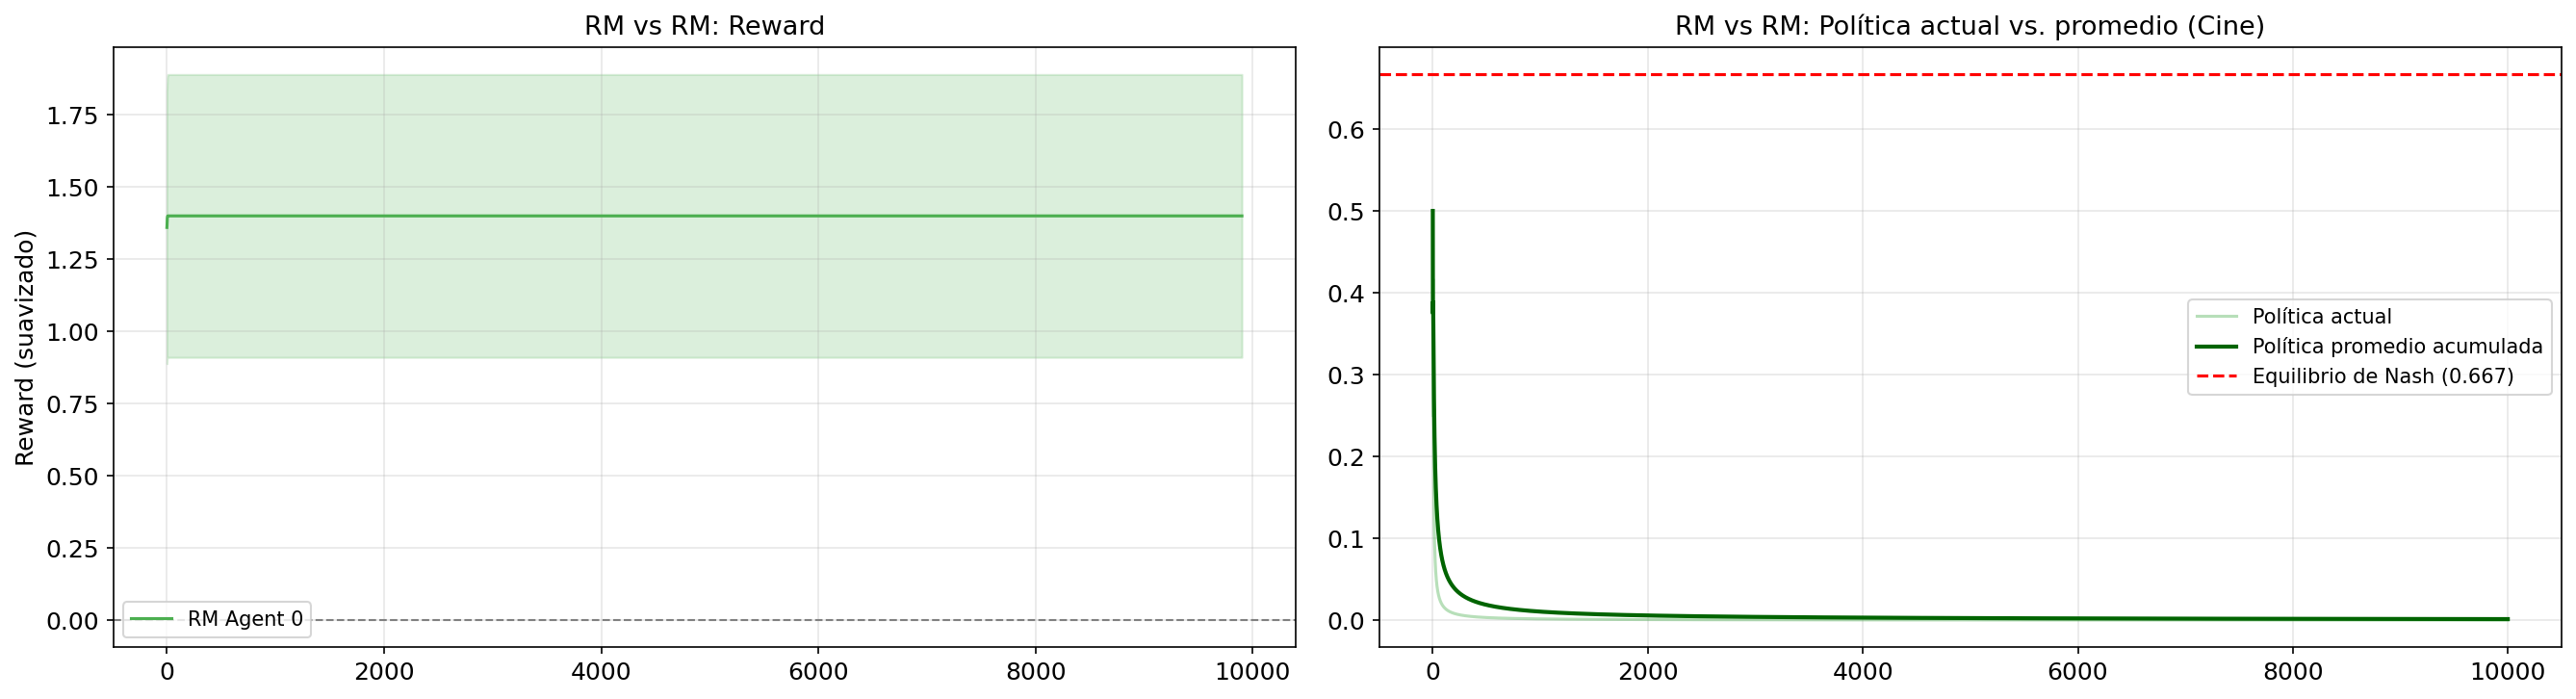

Política final FP (promedio sobre seeds):
  Agent 0: [0.4 0.6]
  Agent 1: [0.4 0.6]
  Equilibrio de Nash: [0.667 0.333]


In [33]:

rewards_rm, pol0_rm, pol1_rm = run_experiment_and_plot(
    BoS, RegretMatching, RegretMatching,
    NE=NE_BOS, color=COLORS['RM'],
    game_name='BoS', experiment_name='RM_vs_RM',
    agent0_label='RM', agent1_label='RM',
    action_label='Cine', action_idx=0,
    n_episodes=N_EPISODES, n_seeds=N_SEEDS,
)


#### FP vs FP

Saved → results/BoS/FP_vs_FP/results.json


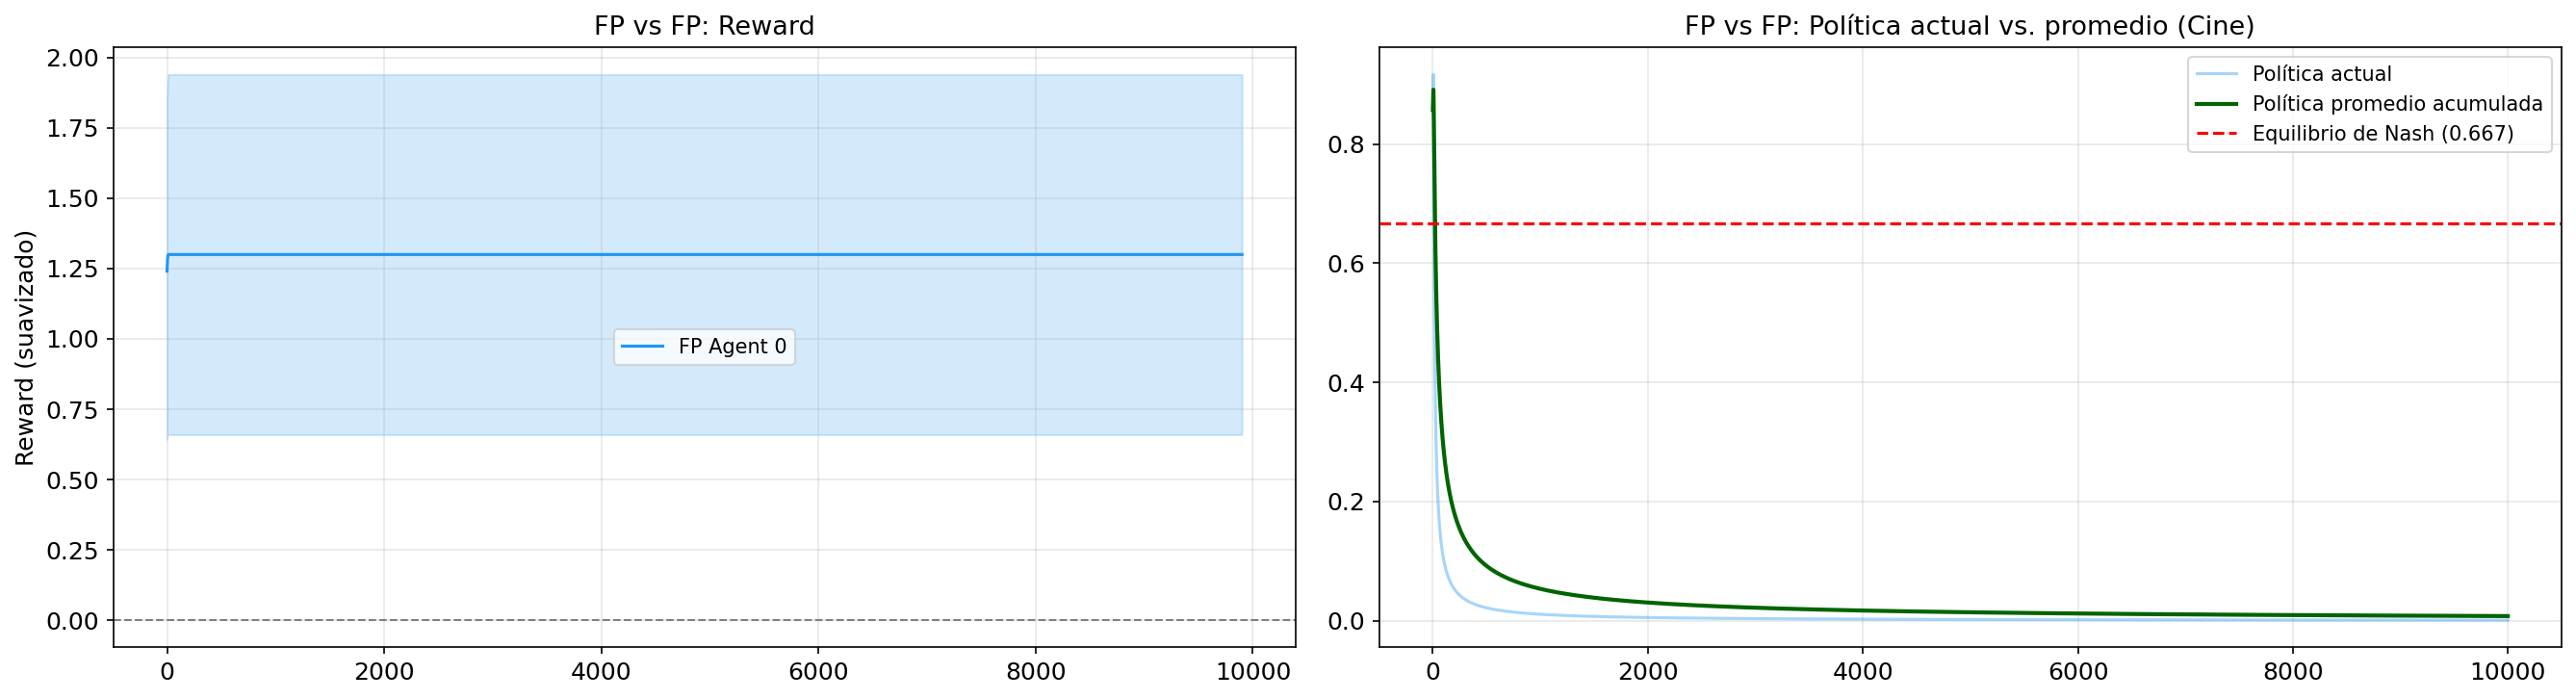

Política final FP (promedio sobre seeds):
  Agent 0: [0.467 0.533]
  Agent 1: [0.433 0.567]
  Equilibrio de Nash: [0.667 0.333]


In [34]:

rewards_fp, pol0_fp, pol1_fp = run_experiment_and_plot(
    BoS, FictitiousPlay, FictitiousPlay,
    NE=NE_BOS, color=COLORS['FP'],
    game_name='BoS', experiment_name='FP_vs_FP',
    agent0_label='FP', agent1_label='FP',
    action_label='Cine', action_idx=0,
    n_episodes=N_EPISODES, n_seeds=N_SEEDS,
)


#### IQL vs IQL

Saved → results/BoS/IQL_vs_IQL/results.json


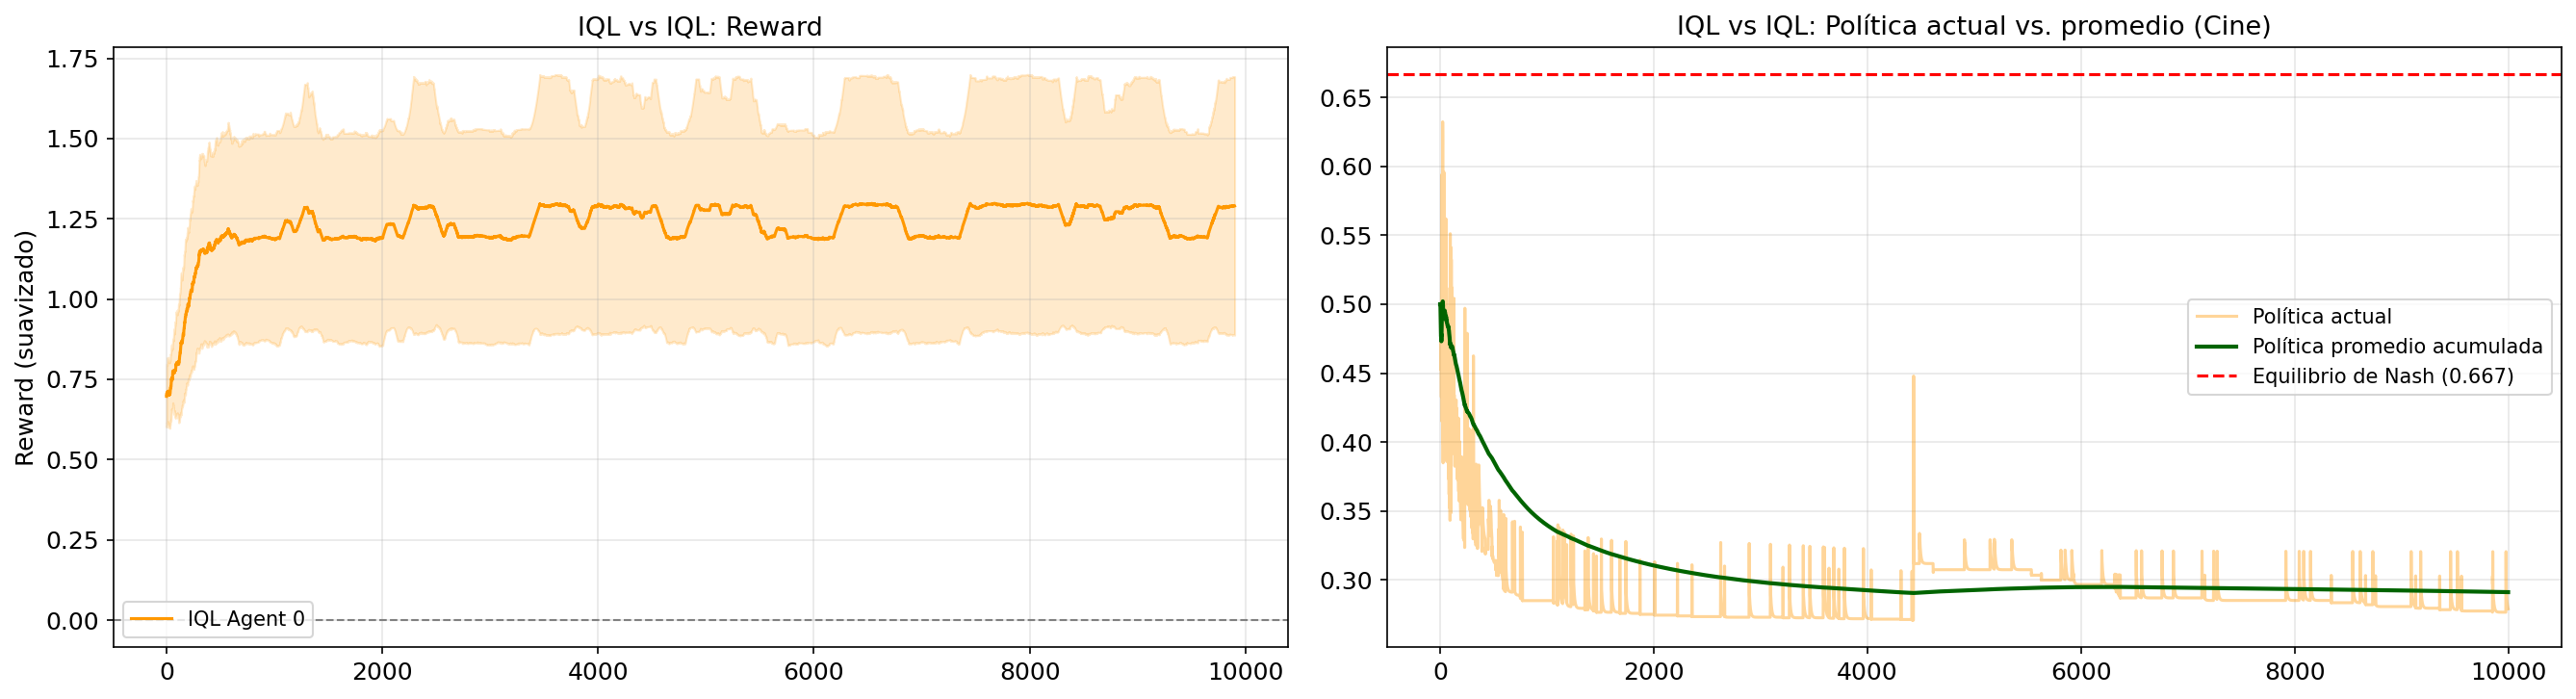

Política final FP (promedio sobre seeds):
  Agent 0: [0.459 0.541]
  Agent 1: [0.305 0.695]
  Equilibrio de Nash: [0.667 0.333]


In [35]:

rewards_iql, pol0_iql, pol1_iql = run_experiment_and_plot(
    BoS, IndependentQLearning, IndependentQLearning,
    NE=NE_BOS, color=COLORS['IQL'],
    game_name='BoS', experiment_name='IQL_vs_IQL',
    agent0_label='IQL', agent1_label='IQL',
    action_label='Cine', action_idx=0,
    n_episodes=N_EPISODES, n_seeds=N_SEEDS,
    agent0_kwargs=IQL_KWARGS, agent1_kwargs=IQL_KWARGS,
)


#### JAL-AM vs JAL-AM

Saved → results/BoS/JALAM_vs_JALAM/results.json


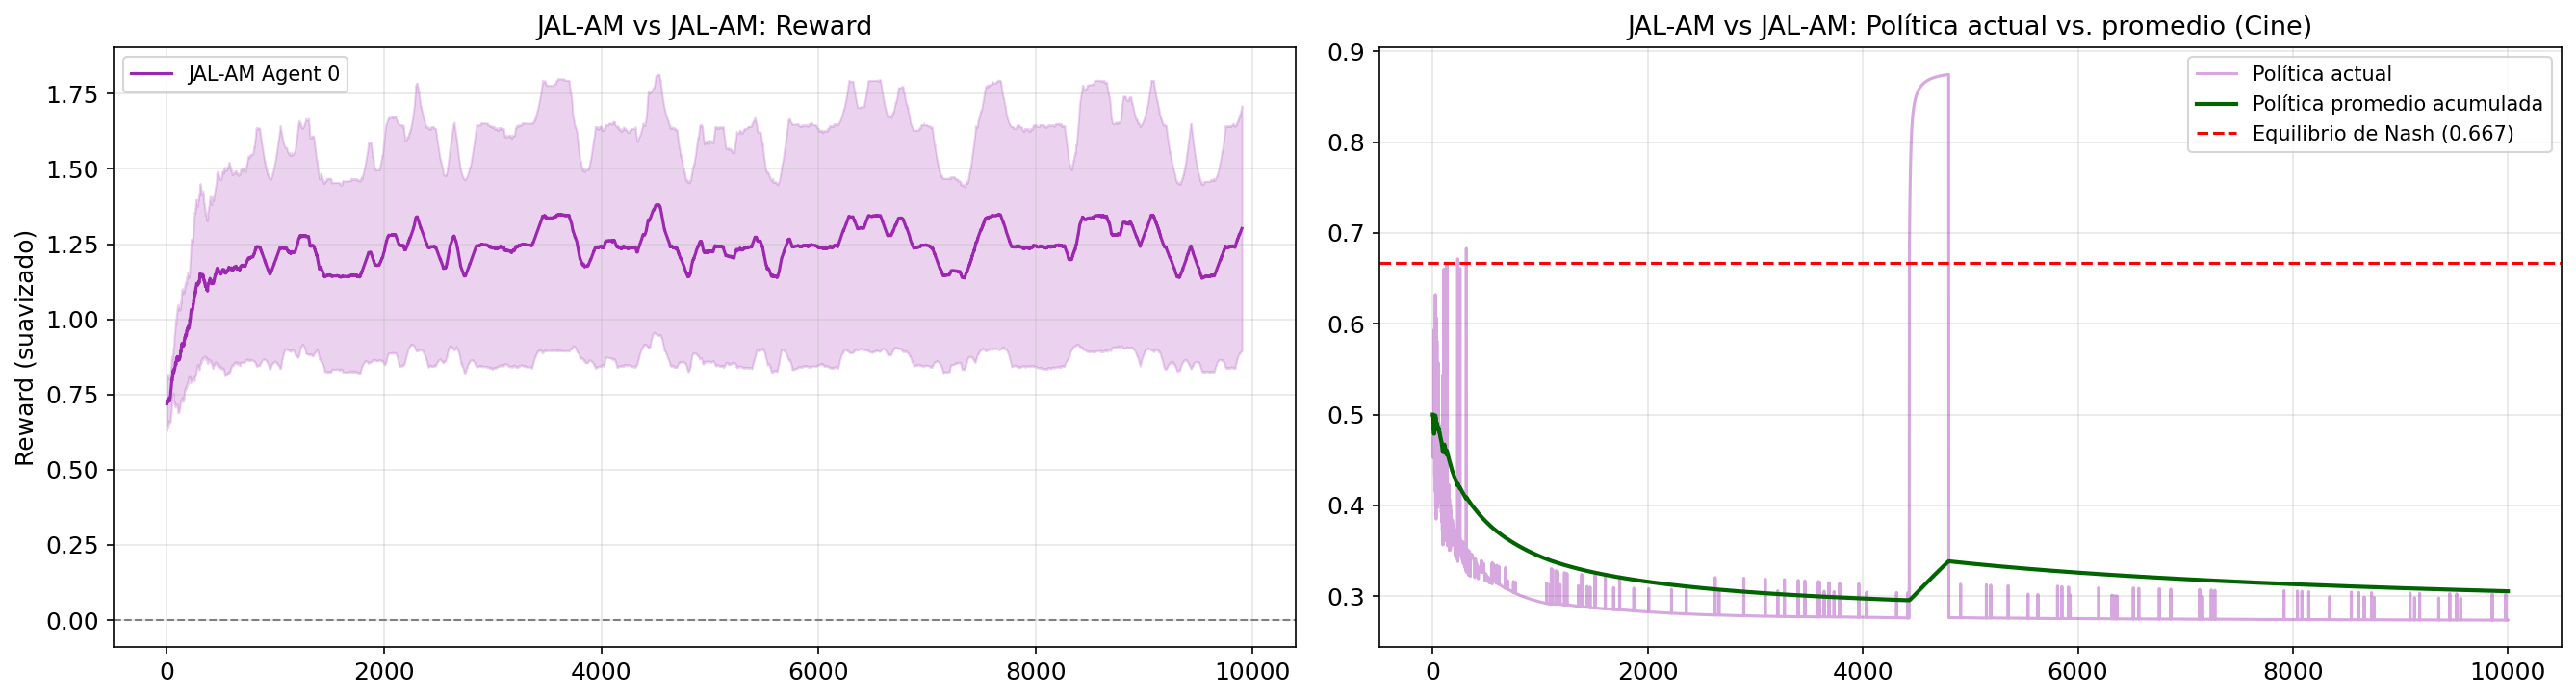

Política final FP (promedio sobre seeds):
  Agent 0: [0.464 0.536]
  Agent 1: [0.313 0.687]
  Equilibrio de Nash: [0.667 0.333]


In [36]:

rewards_jal, pol0_jal, pol1_jal = run_experiment_and_plot(
    BoS, JointActionLearningAM, JointActionLearningAM,
    NE=NE_BOS, color=COLORS['JAL-AM'],
    game_name='BoS', experiment_name='JALAM_vs_JALAM',
    agent0_label='JAL-AM', agent1_label='JAL-AM',
    action_label='Cine', action_idx=0,
    n_episodes=N_EPISODES, n_seeds=N_SEEDS,
    agent0_kwargs=JALAM_KWARGS, agent1_kwargs=JALAM_KWARGS,
)


#### FP vs RM

Saved → results/BoS/FP_vs_RM/results.json


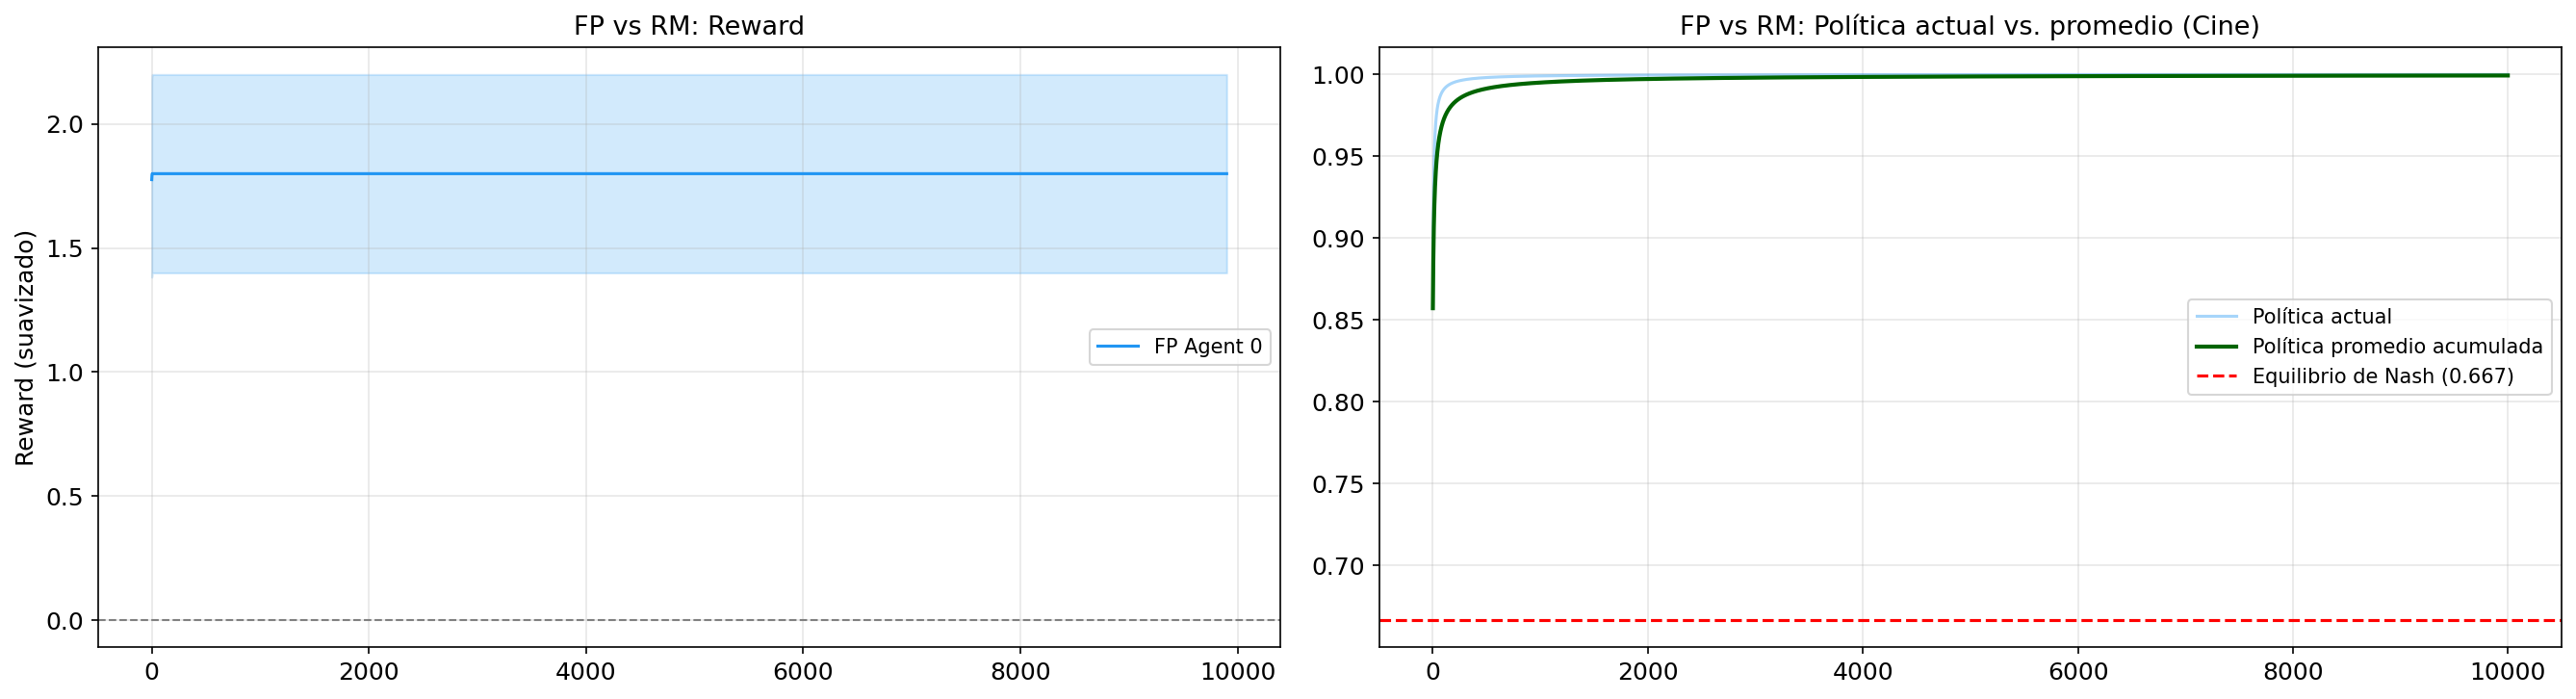

Política final FP (promedio sobre seeds):
  Agent 0: [0.8 0.2]
  Agent 1: [0.8 0.2]
  Equilibrio de Nash: [0.667 0.333]


In [37]:

rewards_fp_rm, pol0_fp_rm, pol1_fp_rm = run_experiment_and_plot(
    BoS, FictitiousPlay, RegretMatching,
    NE=NE_BOS, color=COLORS['FP'], color1=COLORS['RM'],
    game_name='BoS', experiment_name='FP_vs_RM',
    agent0_label='FP', agent1_label='RM',
    action_label='Cine', action_idx=0,
    n_episodes=N_EPISODES, n_seeds=N_SEEDS,
)


#### Todos vs Random

Saved → results/BoS/RM_vs_Random/results.json
Saved → results/BoS/FP_vs_Random/results.json
Saved → results/BoS/IQL_vs_Random/results.json
Saved → results/BoS/JALAM_vs_Random/results.json


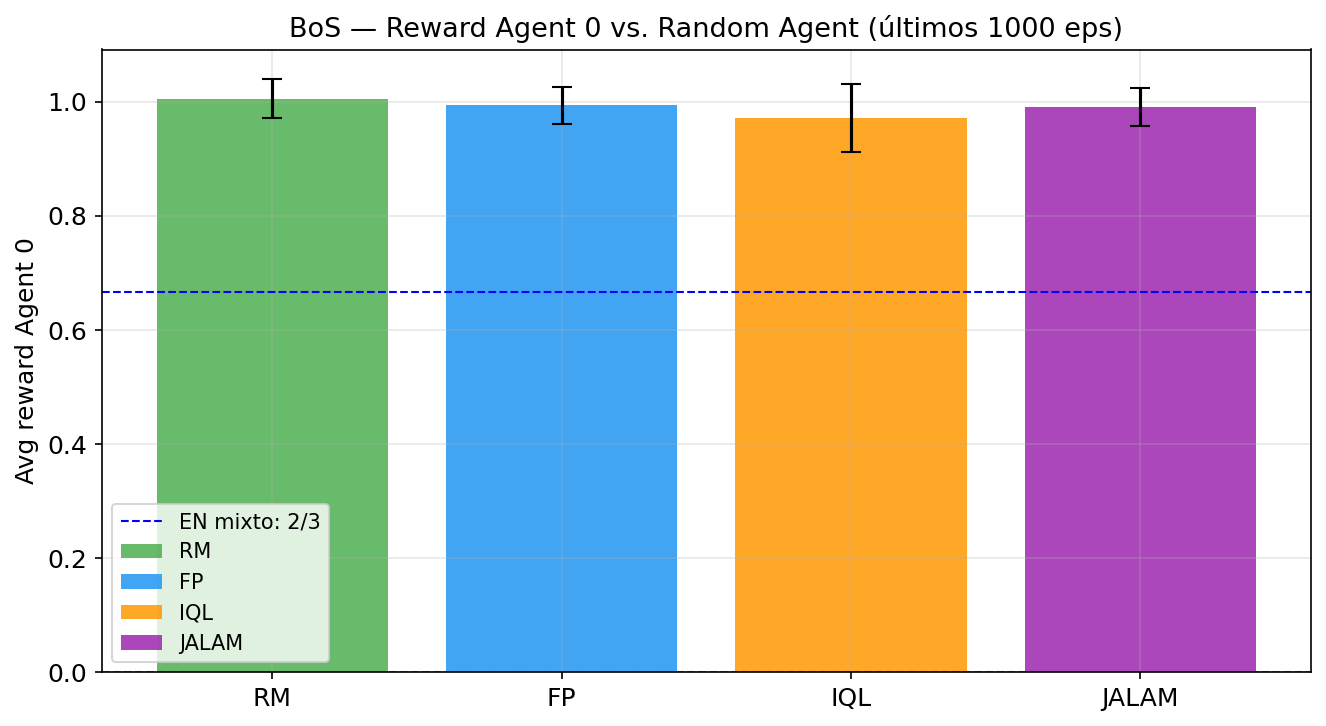

In [38]:

matchups_random_bos = {
    'RM_vs_Random':    (RegretMatching,        RandomAgent, {}, {}),
    'FP_vs_Random':    (FictitiousPlay,        RandomAgent, {}, {}),
    'IQL_vs_Random':   (IndependentQLearning,  RandomAgent, IQL_KWARGS, {}),
    'JALAM_vs_Random': (JointActionLearningAM, RandomAgent, JALAM_KWARGS, {}),
}
vs_random_bos = {}
for name, (cls0, cls1, kw0, kw1) in matchups_random_bos.items():
    r, p0, p1 = run_experiment(BoS, cls0, cls1, N_EPISODES, N_SEEDS,
                               agent0_kwargs=kw0, agent1_kwargs=kw1)
    vs_random_bos[name] = (r, p0, p1)
    save_results('BoS', name, r, p0, p1)

fig, ax = plt.subplots(figsize=(9, 5))
for i, (name, (r, _, _)) in enumerate(vs_random_bos.items()):
    mean_r = r[:, -1000:, 0].mean()
    std_r  = r[:, -1000:, 0].mean(axis=1).std()
    algo = name.split('_vs_')[0]
    ax.bar(i, mean_r, yerr=std_r, color=COLORS.get(algo, 'gray'),
           capsize=5, label=algo, alpha=0.85)
ax.set_xticks(range(len(matchups_random_bos)))
ax.set_xticklabels([n.split('_vs_')[0] for n in matchups_random_bos])
ax.set_title('BoS — Reward Agent 0 vs. Random Agent (últimos 1000 eps)')
ax.set_ylabel('Avg reward Agent 0')
ax.axhline(2/3, ls='--', c='blue',  lw=1, label='EN mixto: 2/3')
ax.axhline(0,   ls='--', c='gray',  lw=1)
ax.legend()
plt.tight_layout()
plt.savefig('figures/BoS/vs_random_comparison.png', dpi=150)
plt.show()


#### Cross-play: Tasa de Coordinación y Reward Promedio

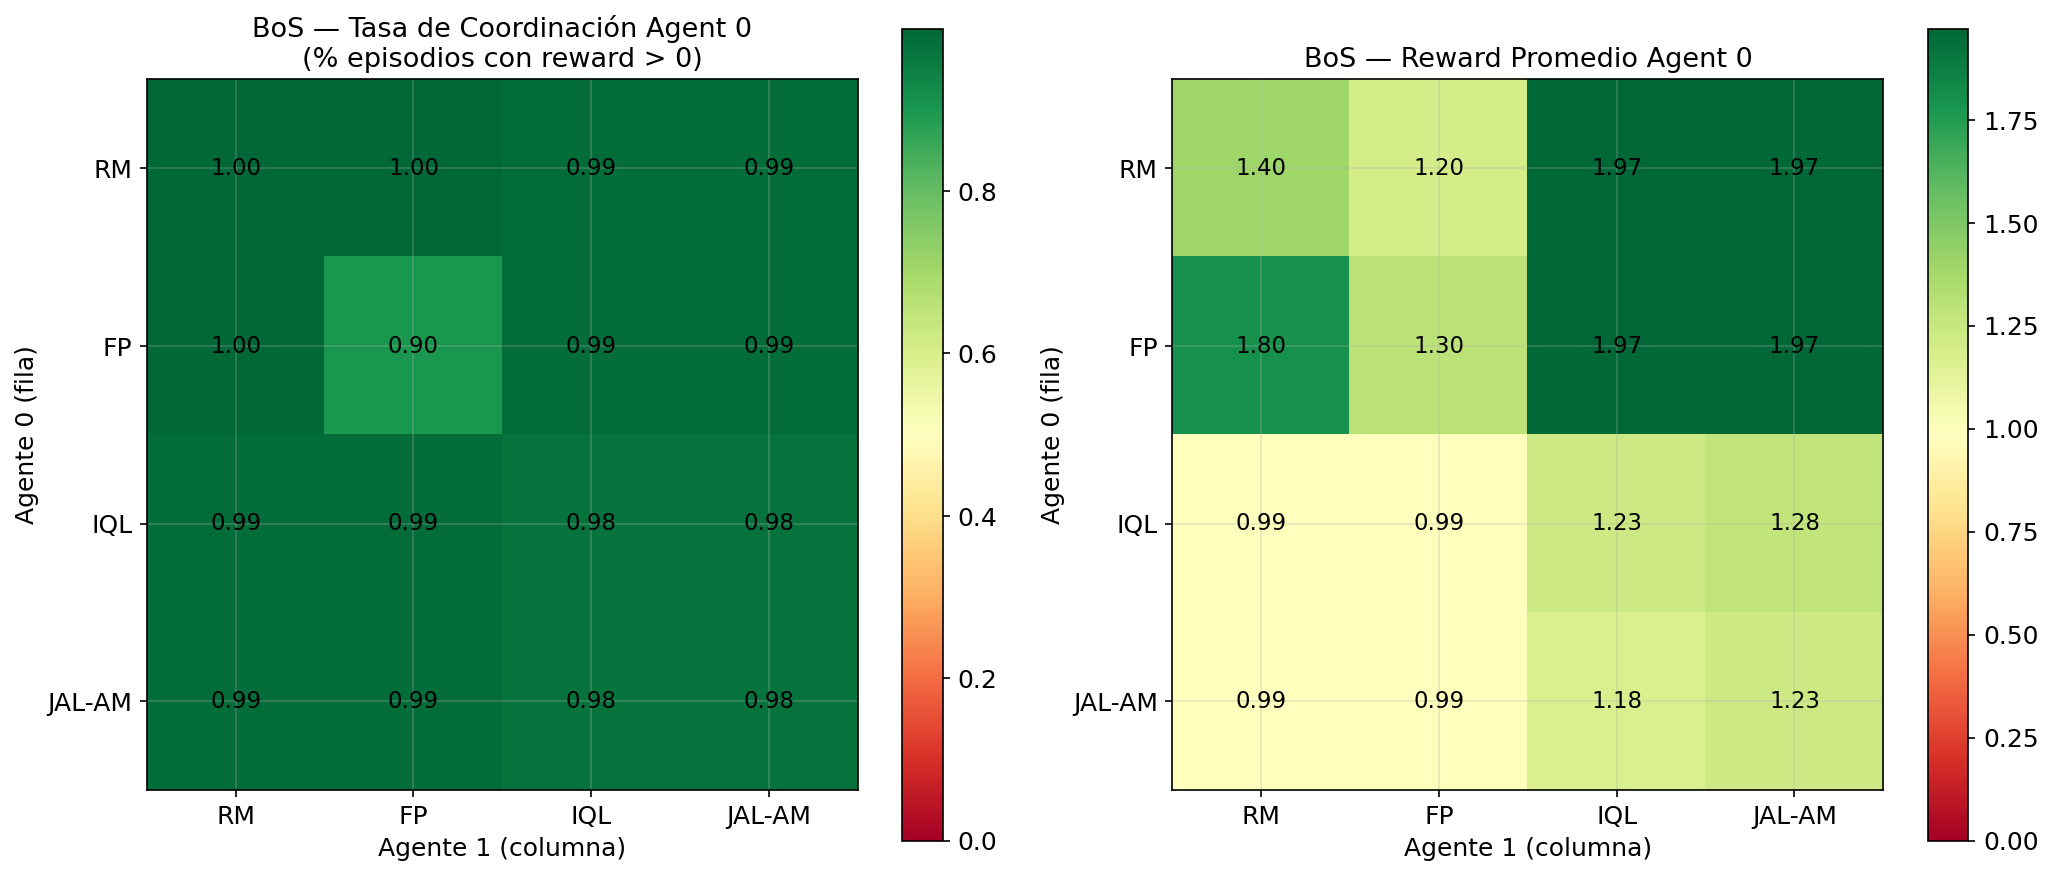

In [39]:

algo_classes_bos = {
    'RM':     (RegretMatching,        {}),
    'FP':     (FictitiousPlay,        {}),
    'IQL':    (IndependentQLearning,  IQL_KWARGS),
    'JAL-AM': (JointActionLearningAM, JALAM_KWARGS),
}
algos_bos = list(algo_classes_bos.keys())
coord_rate_bos = np.zeros((len(algos_bos), len(algos_bos)))
avg_reward_bos = np.zeros((len(algos_bos), len(algos_bos)))

for i, a0 in enumerate(algos_bos):
    for j, a1 in enumerate(algos_bos):
        cls0, kw0 = algo_classes_bos[a0]
        cls1, kw1 = algo_classes_bos[a1]
        r, _, _ = run_experiment(BoS, cls0, cls1, N_EPISODES, N_SEEDS,
                                 agent0_kwargs=kw0, agent1_kwargs=kw1)
        coord_rate_bos[i, j] = (r[:, :, 0] > 0).mean()   # % episodios coordinados
        avg_reward_bos[i, j]  = r[:, :, 0].mean()          # reward medio agent_0

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, data, title, fmt in [
    (axes[0], coord_rate_bos, 'Tasa de Coordinación Agent 0\n(% episodios con reward > 0)', '{:.2f}'),
    (axes[1], avg_reward_bos, 'Reward Promedio Agent 0',                                    '{:.2f}'),
]:
    im = ax.imshow(data, cmap='RdYlGn', vmin=0, vmax=data.max())
    ax.set_xticks(range(len(algos_bos))); ax.set_yticks(range(len(algos_bos)))
    ax.set_xticklabels(algos_bos); ax.set_yticklabels(algos_bos)
    ax.set_xlabel('Agente 1 (columna)'); ax.set_ylabel('Agente 0 (fila)')
    ax.set_title(f'BoS — {title}')
    plt.colorbar(im, ax=ax)
    for ii in range(len(algos_bos)):
        for jj in range(len(algos_bos)):
            ax.text(jj, ii, fmt.format(data[ii, jj]), ha='center', va='center', fontsize=11)
plt.tight_layout()
plt.savefig('figures/BoS/cross_play_matrix.png', dpi=150)
plt.show()


#### Comparación final: todos los algoritmos

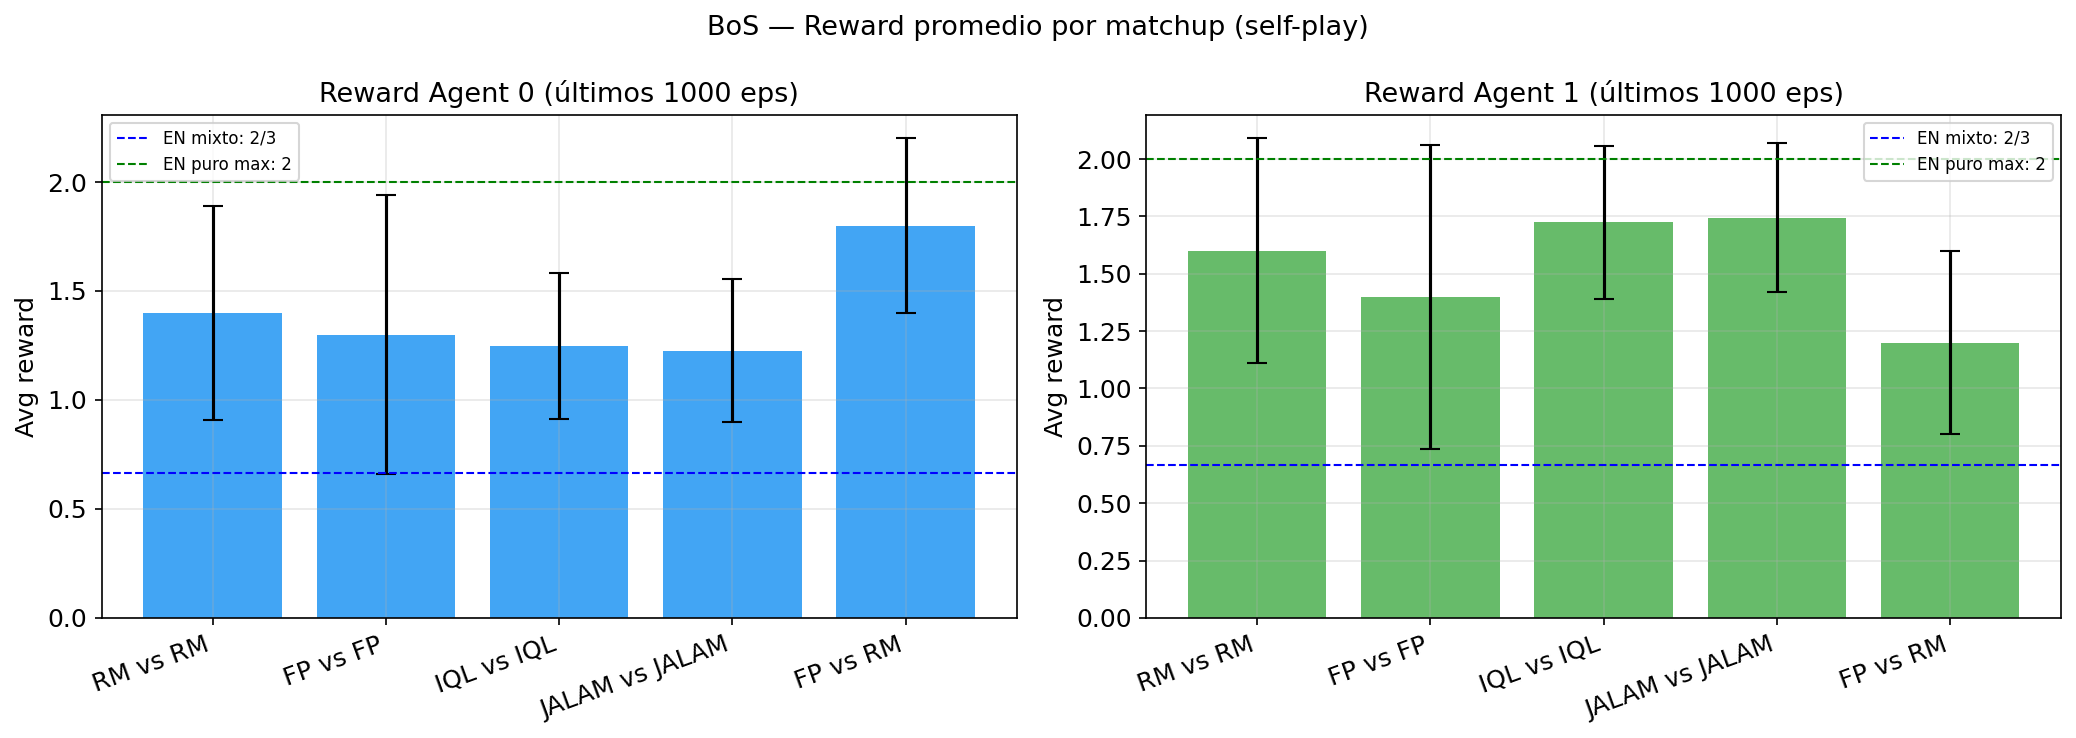

Matchup                       Política final A0   Dist NE (media)   Dist NE (std)
---------------------------------------------------------------------------------
RM vs RM                              [0.4 0.6]            1.0663          0.3265
FP vs FP                          [0.467 0.533]            0.9320          0.4418
IQL vs IQL                        [0.458 0.542]            0.6736          0.1437
JALAM vs JALAM                    [0.445 0.555]            0.6823          0.1434
FP vs RM                              [0.8 0.2]            0.7987          0.2667


In [40]:

# Reward promedio (últimos 1000 eps) por matchup
self_play_results = {
    'RM vs RM':       (rewards_rm,    pol0_rm,    pol1_rm),
    'FP vs FP':       (rewards_fp,    pol0_fp,    pol1_fp),
    'IQL vs IQL':     (rewards_iql,   pol0_iql,   pol1_iql),
    'JALAM vs JALAM': (rewards_jal,   pol0_jal,   pol1_jal),
    'FP vs RM':       (rewards_fp_rm, pol0_fp_rm, pol1_fp_rm),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
names    = list(self_play_results.keys())
r0_means = [self_play_results[n][0][:, -1000:, 0].mean() for n in names]
r1_means = [self_play_results[n][0][:, -1000:, 1].mean() for n in names]
r0_stds  = [self_play_results[n][0][:, -1000:, 0].mean(axis=1).std() for n in names]
r1_stds  = [self_play_results[n][0][:, -1000:, 1].mean(axis=1).std() for n in names]
x = range(len(names))

axes[0].bar(x, r0_means, yerr=r0_stds, capsize=5, alpha=0.85, color=COLORS['FP'])
axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=20, ha='right')
axes[0].set_title('Reward Agent 0 (últimos 1000 eps)'); axes[0].set_ylabel('Avg reward')
axes[0].axhline(2/3, ls='--', c='blue',  lw=1, label='EN mixto: 2/3')
axes[0].axhline(2,   ls='--', c='green', lw=1, label='EN puro max: 2'); axes[0].legend(fontsize=8)

axes[1].bar(x, r1_means, yerr=r1_stds, capsize=5, alpha=0.85, color=COLORS['RM'])
axes[1].set_xticks(x); axes[1].set_xticklabels(names, rotation=20, ha='right')
axes[1].set_title('Reward Agent 1 (últimos 1000 eps)'); axes[1].set_ylabel('Avg reward')
axes[1].axhline(2/3, ls='--', c='blue',  lw=1, label='EN mixto: 2/3')
axes[1].axhline(2,   ls='--', c='green', lw=1, label='EN puro max: 2'); axes[1].legend(fontsize=8)

plt.suptitle('BoS — Reward promedio por matchup (self-play)', fontsize=13)
plt.tight_layout()
plt.savefig('figures/BoS/reward_comparison.png', dpi=150)
plt.show()

# Tabla resumen
from utils.plotting import summary_table
summary_table(self_play_results, ne=NE_BOS)


## Conclusiones
- Generalmente los agentes tienden a buscar los equilibrios, salvo el agente Random y el caso particular en donde IQL juega vs JAL-AM.
- No se han encontrado casos en los que los agentes converjan a equilibrios correlacionados, siempre se tiende a converger hacia los puros.
- Fictitious y Matching son los agentes que convergen más rápido, mientras que JAL-AM lo hace un poco más lento, e IQL se muestra como el más inestable, aunque en algunos casos logra converger a equilibrios puros.